# Hand Landmark Preprocessing & Visualization

Notebook này trực quan hóa `collect/hand_dataset.csv` trước và sau tiền xử lý.

Các hình chính:
- Phân bố class hand gesture.
- Range feature raw/normalized.
- Overlay landmark bàn tay theo từng class.
- Finger length proxy theo class.
- PCA 2D và confusion matrix train nhanh.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 30)

In [2]:
NOTEBOOK_DIR = Path.cwd()
candidate_paths = [
    NOTEBOOK_DIR / ".." / "collect" / "hand_dataset.csv",
    Path("../collect/hand_dataset.csv"),
    Path("DiQuaMuaHaa/backend/driver_training/collect/hand_dataset.csv"),
]
csv_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Không tìm thấy collect/hand_dataset.csv")

OUT_DIR = (NOTEBOOK_DIR / "outputs" / "hand").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
csv_path, OUT_DIR

(WindowsPath('D:/deployweb/conghienmegrge/DiQuaMuaHaa/backend/driver_training/collect/hand_dataset.csv'),
 WindowsPath('D:/deployweb/conghienmegrge/DiQuaMuaHaa/backend/driver_training/analysis/outputs/hand'))

In [3]:
df = pd.read_csv(csv_path)
labels = df["label"].astype(str)
X = df.drop(columns=["label"]).astype("float32")
n_samples, n_features = X.shape
n_landmarks = n_features // 3

print(f"CSV: {csv_path}")
print(f"Samples: {n_samples}")
print(f"Features: {n_features}")
print(f"Landmarks: {n_landmarks}")
display(labels.value_counts())

if n_features != 63:
    warnings.warn("Hand dataset thường nên là 63 feature = 21 landmarks * 3.")
if labels.value_counts().min() < 30:
    warnings.warn("Có class rất ít mẫu; train sẽ dễ lệch. Nhìn kỹ class distribution.")

CSV: D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\driver_training\collect\hand_dataset.csv
Samples: 1212
Features: 63
Landmarks: 21


label
open         300
map          300
music        300
phonecall    300
no_sign       12
Name: count, dtype: int64

C:\Users\duong\AppData\Local\Temp\ipykernel_5432\384126272.py:16: UserWarning: Có class rất ít mẫu; train sẽ dễ lệch. Nhìn kỹ class distribution.
  warnings.warn("Có class rất ít mẫu; train sẽ dễ lệch. Nhìn kỹ class distribution.")


## 1. Trước tiền xử lý: class balance và feature range

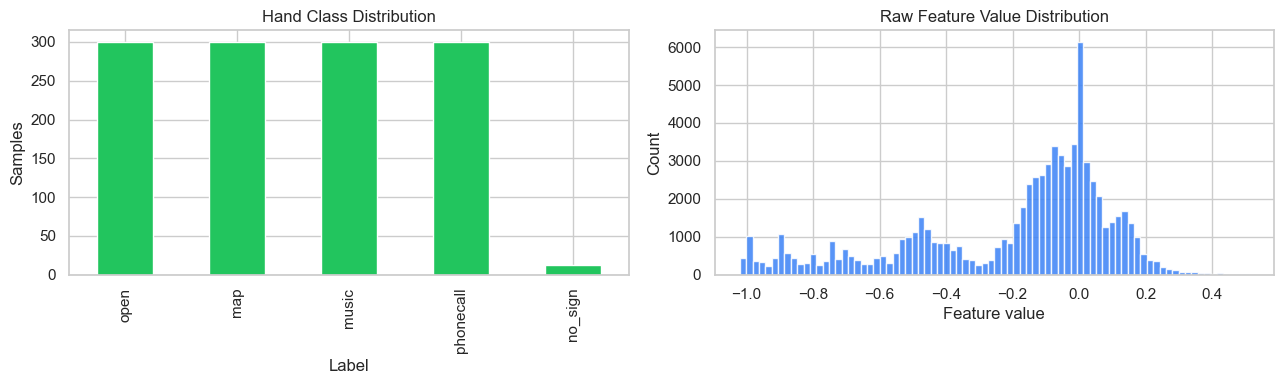

,missing,min,max,mean,std
0,0,-1.019761,0.509468,-0.202362,0.312621


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels.value_counts().plot(kind="bar", ax=axes[0], color="#22c55e")
axes[0].set_title("Hand Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Samples")

flat = X.to_numpy().ravel()
axes[1].hist(flat, bins=80, color="#3b82f6", alpha=0.85)
axes[1].set_title("Raw Feature Value Distribution")
axes[1].set_xlabel("Feature value")
axes[1].set_ylabel("Count")
plt.tight_layout()
fig.savefig(OUT_DIR / "01_class_and_feature_distribution.png", dpi=160)
plt.show()

display(pd.DataFrame({
    "missing": [int(X.isna().sum().sum())],
    "min": [float(X.min().min())],
    "max": [float(X.max().max())],
    "mean": [float(X.to_numpy().mean())],
    "std": [float(X.to_numpy().std())],
}))

## 2. Vẽ landmark bàn tay

Dataset này đã normalize kiểu cổ tay gần `(0,0,0)` và scale theo biên độ lớn nhất. Ta vẫn vẽ lại để bắt lỗi label/pose.

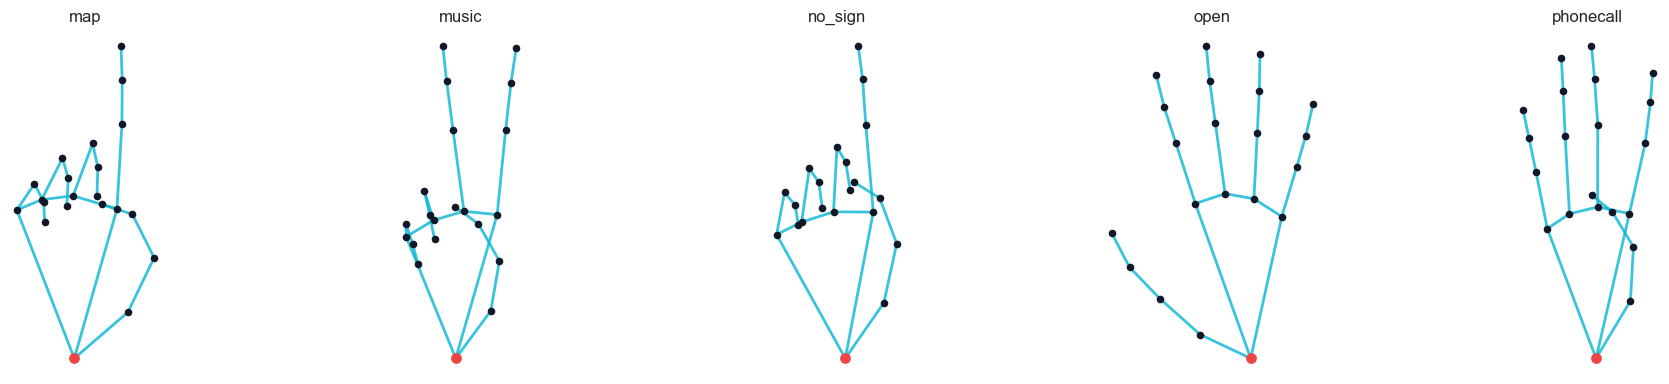

In [5]:
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),(0,17)
]

def to_hand_points(row):
    return np.asarray(row, dtype=np.float32).reshape(21, 3)

def plot_hand(points, ax=None, title="", color="#06b6d4"):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    for a, b in HAND_CONNECTIONS:
        ax.plot([points[a,0], points[b,0]], [-points[a,1], -points[b,1]], color=color, lw=2, alpha=0.8)
    ax.scatter(points[:,0], -points[:,1], s=20, color="#111827", zorder=3)
    ax.scatter(points[0,0], -points[0,1], s=45, color="#ef4444", zorder=4, label="wrist")
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.axis("off")
    return ax

unique_labels = sorted(labels.unique())
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))
if len(unique_labels) == 1:
    axes = [axes]
for ax, label in zip(axes, unique_labels):
    idx = labels[labels == label].index[0]
    plot_hand(to_hand_points(X.iloc[idx].values), ax=ax, title=label)
plt.tight_layout()
fig.savefig(OUT_DIR / "02_hand_samples_by_class.png", dpi=160)
plt.show()

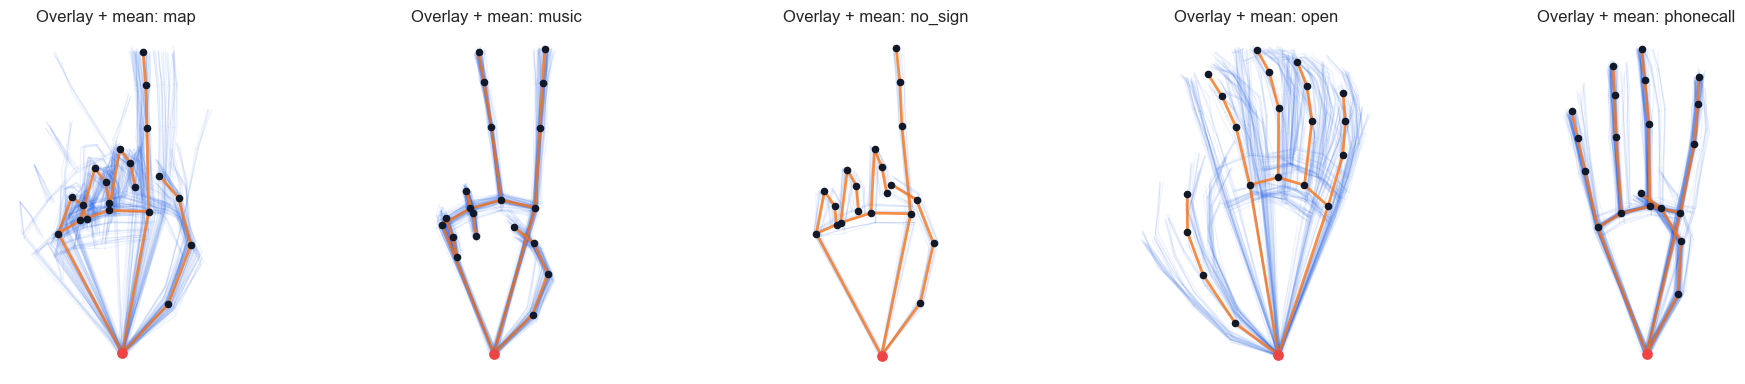

In [6]:
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))
if len(unique_labels) == 1:
    axes = [axes]

for ax, label in zip(axes, unique_labels):
    subset = X[labels == label].head(80)
    for _, row in subset.iterrows():
        pts = to_hand_points(row.values)
        for a, b in HAND_CONNECTIONS:
            ax.plot([pts[a,0], pts[b,0]], [-pts[a,1], -pts[b,1]], color="#2563eb", lw=0.8, alpha=0.08)
    mean_pts = np.stack([to_hand_points(r) for r in subset.to_numpy()]).mean(axis=0)
    plot_hand(mean_pts, ax=ax, title=f"Overlay + mean: {label}", color="#f97316")
plt.tight_layout()
fig.savefig(OUT_DIR / "03_hand_overlay_mean_by_class.png", dpi=160)
plt.show()

## 3. Feature engineering nhỏ: độ dài ngón tay proxy

Không nhất thiết dùng để train, nhưng rất hữu ích để xem gesture có hình học khác nhau không.

,thumb,index,middle,ring,pinky
label,,,,,
map,0.640,1.012,0.807,0.752,0.676
music,0.527,1.002,1.005,0.700,0.609
no_sign,0.659,1.012,0.822,0.767,0.711
open,0.641,0.970,1.022,0.969,0.855
phonecall,0.601,0.924,1.003,0.966,0.834


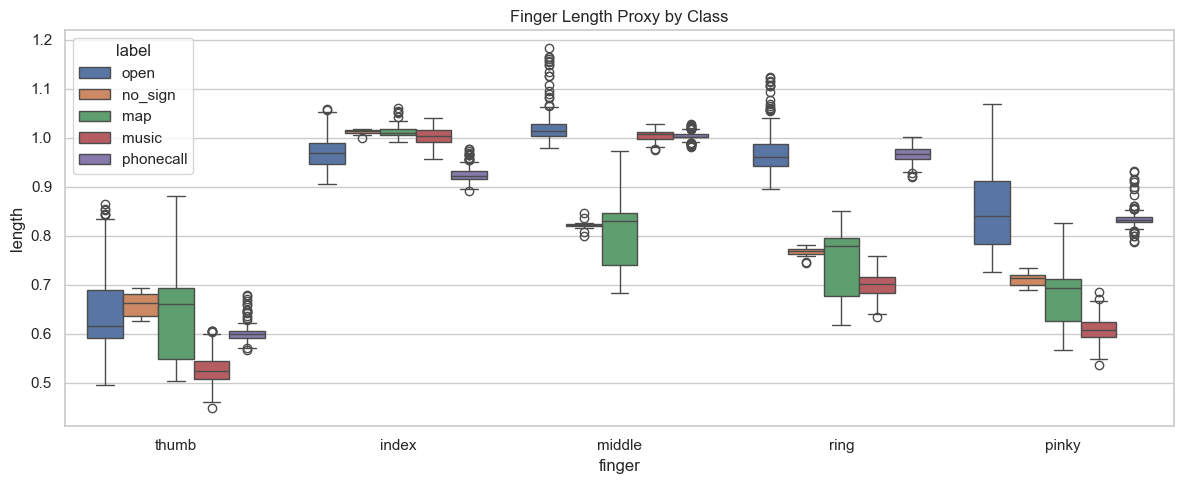

In [7]:
FINGERS = {
    "thumb": [0,1,2,3,4],
    "index": [0,5,6,7,8],
    "middle": [0,9,10,11,12],
    "ring": [0,13,14,15,16],
    "pinky": [0,17,18,19,20],
}

def path_len(points, ids):
    return sum(np.linalg.norm(points[b,:2] - points[a,:2]) for a, b in zip(ids[:-1], ids[1:]))

rows = []
for label, row in zip(labels, X.to_numpy()):
    pts = to_hand_points(row)
    rec = {"label": label}
    for name, ids in FINGERS.items():
        rec[name] = path_len(pts, ids)
    rows.append(rec)
finger_df = pd.DataFrame(rows)
display(finger_df.groupby("label").mean().round(3))

melted = finger_df.melt(id_vars="label", var_name="finger", value_name="length")
fig, ax = plt.subplots(figsize=(12, 5))
if sns:
    sns.boxplot(data=melted, x="finger", y="length", hue="label", ax=ax)
else:
    melted.boxplot(column="length", by=["finger", "label"], ax=ax)
ax.set_title("Finger Length Proxy by Class")
plt.tight_layout()
fig.savefig(OUT_DIR / "04_finger_length_proxy.png", dpi=160)
plt.show()

## 4. PCA + train nhanh

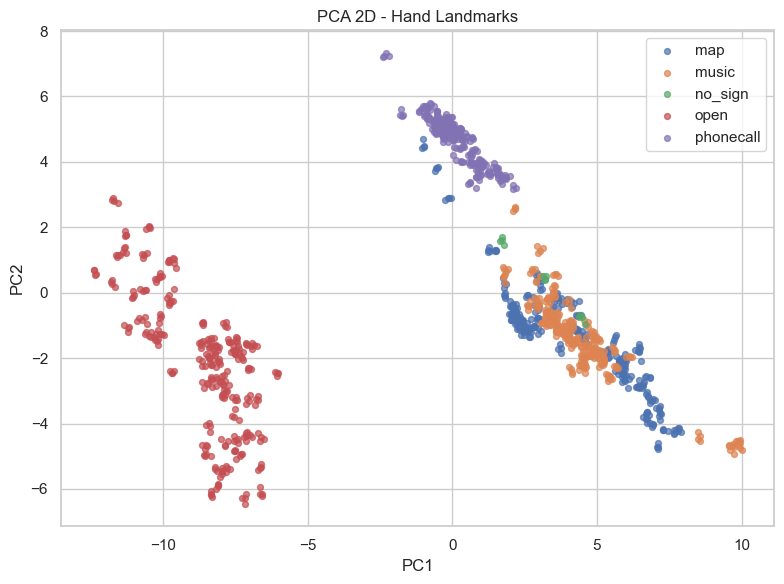

In [8]:
Xs = StandardScaler().fit_transform(X.to_numpy())
pca = PCA(n_components=2, random_state=42).fit_transform(Xs)

fig, ax = plt.subplots(figsize=(8, 6))
for label in unique_labels:
    mask = labels.values == label
    ax.scatter(pca[mask, 0], pca[mask, 1], s=18, alpha=0.7, label=label)
ax.set_title("PCA 2D - Hand Landmarks")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "05_pca_hand_landmarks.png", dpi=160)
plt.show()

              precision    recall  f1-score   support

         map      1.000     1.000     1.000        60
       music      1.000     1.000     1.000        60
     no_sign      1.000     1.000     1.000         3
        open      1.000     1.000     1.000        60
   phonecall      1.000     1.000     1.000        60

    accuracy                          1.000       243
   macro avg      1.000     1.000     1.000       243
weighted avg      1.000     1.000     1.000       243



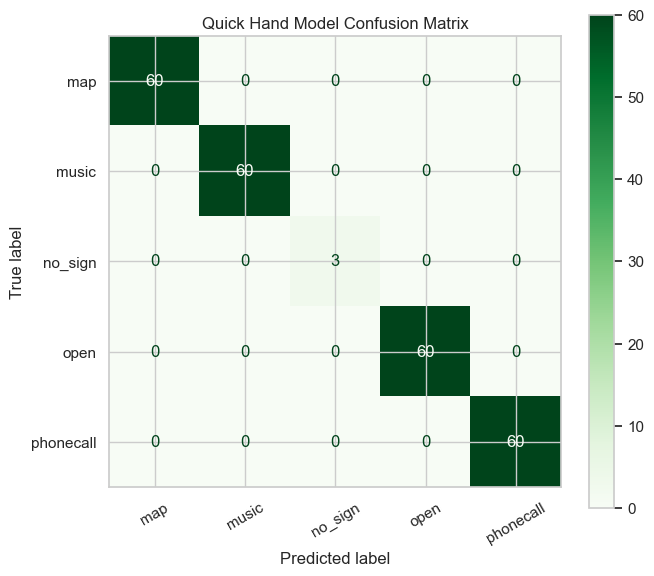

In [9]:
class_counts = labels.value_counts()
stratify = labels.values if class_counts.min() >= 2 else None
X_train, X_val, y_train, y_val = train_test_split(X.to_numpy(), labels.values, test_size=0.2, random_state=42, stratify=stratify)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), random_state=42, max_iter=250)),
])
model.fit(X_train, y_train)
pred = model.predict(X_val)
print(classification_report(y_val, pred, digits=3))

cm_labels = sorted(labels.unique())
cm = confusion_matrix(y_val, pred, labels=cm_labels)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=cm_labels).plot(ax=ax, cmap="Greens", values_format="d", xticks_rotation=30)
ax.set_title("Quick Hand Model Confusion Matrix")
plt.tight_layout()
fig.savefig(OUT_DIR / "06_confusion_matrix_hand.png", dpi=160)
plt.show()

## Ghi chú

Nếu class `no_sign` quá ít mẫu so với các class khác, model rất dễ bỏ qua class này. Nên thu thêm `no_sign` ở nhiều góc tay/ánh sáng hơn.